BLOCK 1 — Imports, Load & Cleaning

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor": "#0f0f0f",
    "axes.facecolor": "#1a1a2e",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "axes.titlecolor": "white",
    "grid.color": "#2a2a4a",
    "figure.dpi": 130
})

df = pd.read_csv("datasets/Parent Occupations Data.csv")

# Occupation columns
occ_cols = [c for c in df.columns if c != "Year"]

# Fill NaN with 0 — missing means not reported that year
df[occ_cols] = df[occ_cols].fillna(0)

# Total students per year (sum of all occupations)
df["Total"] = df[occ_cols].sum(axis=1)

print("Shape:", df.shape)
print("\nNull values after cleaning:\n", df.isnull().sum())
print("\nFull Data:\n", df[["Year"] + occ_cols].to_string(index=False))

Shape: (8, 16)

Null values after cleaning:
 Year                 0
Agriculture          0
Business             0
Medical              0
Engineering          0
Law                  0
Teaching/Research    0
Govt Service         0
Public Sector        0
Private Service      0
Defense              0
Architecture         0
Pharmacy             0
Self-Employment      0
Others / No Info     0
Total                0
dtype: int64

Full Data:
  Year  Agriculture  Business  Medical  Engineering  Law  Teaching/Research  Govt Service  Public Sector  Private Service  Defense  Architecture  Pharmacy  Self-Employment  Others / No Info
 2011         2450       513      650          134  985               5212          1346            0.0              259    650.0           0.0       0.0              0.0               997
 2012         2257      4472      701         1052  250               1700          9361            0.0             2419    552.0           0.0       0.0              0.0             

BLOCK 2 — Descriptive Statistics

In [68]:
print("=" * 65)
print("       PARENT OCCUPATION DATA — DESCRIPTIVE STATS")
print("=" * 65)

print(f"\nYears Covered : {df['Year'].min()} – {df['Year'].max()}")
print(f"Total Records : {len(df)} years\n")

# All-time totals per occupation
totals = df[occ_cols].sum().sort_values(ascending=False)
print("📊 All-time Total Students per Parent Occupation:")
for occ, val in totals.items():
    pct = (val / totals.sum()) * 100
    print(f"  {occ:<22} : {int(val):>7,}  ({pct:.1f}%)")

print(f"\n📊 Year-wise Total Students Reported:")
for _, row in df.iterrows():
    print(f"  {int(row['Year'])} : {int(row['Total']):,}")

print(f"\n📊 Dominant Occupation Every Year:")
for _, row in df.iterrows():
    dominant = row[occ_cols].idxmax()
    print(f"  {int(row['Year'])} → {dominant} ({int(row[dominant]):,})")

       PARENT OCCUPATION DATA — DESCRIPTIVE STATS

Years Covered : 2011 – 2018
Total Records : 8 years

📊 All-time Total Students per Parent Occupation:
  Govt Service           :  59,635  (27.8%)
  Business               :  32,279  (15.0%)
  Others / No Info       :  31,299  (14.6%)
  Private Service        :  22,062  (10.3%)
  Agriculture            :  20,110  (9.4%)
  Teaching/Research      :  15,430  (7.2%)
  Public Sector          :  10,076  (4.7%)
  Engineering            :   8,389  (3.9%)
  Self-Employment        :   6,301  (2.9%)
  Medical                :   4,831  (2.2%)
  Law                    :   2,759  (1.3%)
  Defense                :   1,202  (0.6%)
  Pharmacy               :     307  (0.1%)
  Architecture           :     186  (0.1%)

📊 Year-wise Total Students Reported:
  2011 : 13,196
  2012 : 24,112
  2013 : 20,834
  2014 : 27,152
  2015 : 9,978
  2016 : 36,566
  2017 : 51,040
  2018 : 31,988

📊 Dominant Occupation Every Year:
  2011 → Teaching/Research (5,212)
  2012

BLOCK 3 — All-time Share: Horizontal Bar Chart

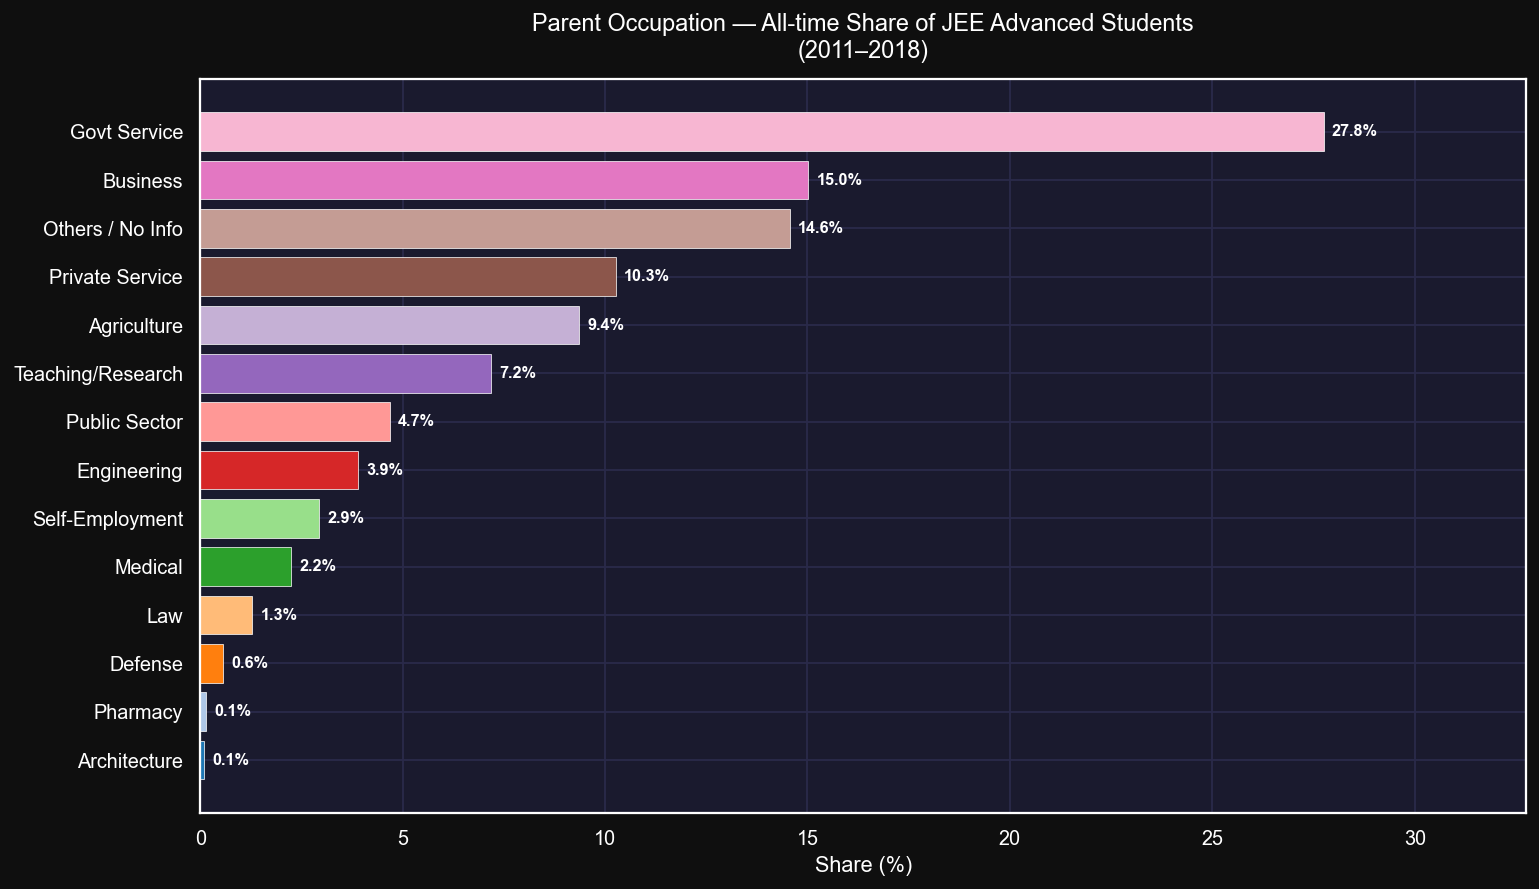

In [69]:
totals = df[occ_cols].sum().sort_values(ascending=True)
pcts   = (totals / totals.sum()) * 100

colors = sns.color_palette("tab20", len(totals))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(totals.index, pcts.values, color=colors, edgecolor="white", linewidth=0.4)

for bar, val in zip(bars, pcts.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9, color="white", fontweight="bold")

ax.set_title("Parent Occupation — All-time Share of JEE Advanced Students\n(2011–2018)", fontsize=13, pad=12)
ax.set_xlabel("Share (%)")
ax.set_xlim(0, pcts.max() + 5)

plt.tight_layout()
plt.savefig("15_occupation_alltime_share.png", bbox_inches="tight")
plt.show()

BLOCK 4 — Stacked Bar: Occupation Mix Each Year

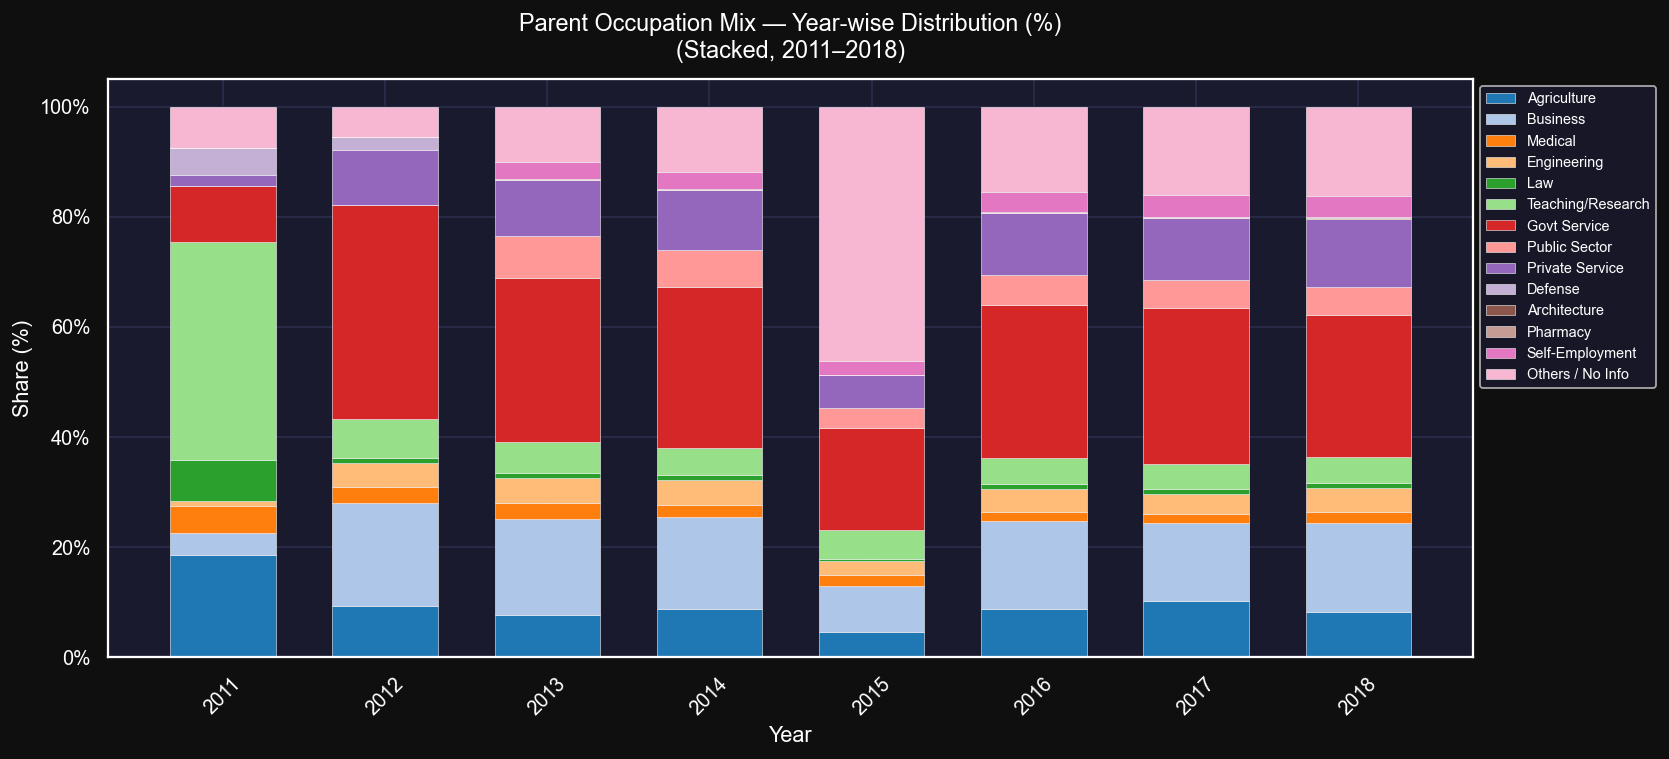

In [70]:
# Normalize to % for fair comparison across years
df_pct = df[occ_cols].div(df["Total"], axis=0) * 100
df_pct["Year"] = df["Year"]

fig, ax = plt.subplots(figsize=(13, 6))

palette = sns.color_palette("tab20", len(occ_cols))
bottom  = np.zeros(len(df))

for col, color in zip(occ_cols, palette):
    ax.bar(df["Year"], df_pct[col], bottom=bottom, label=col,
           color=color, edgecolor="white", linewidth=0.3, width=0.65)
    bottom += df_pct[col].values

ax.set_title("Parent Occupation Mix — Year-wise Distribution (%)\n(Stacked, 2011–2018)", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Share (%)")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f%%"))

plt.tight_layout()
plt.savefig("16_stacked_occupation_mix.png", bbox_inches="tight")
plt.show()

BLOCK 5 — Top 5 Occupations Trend Over Years

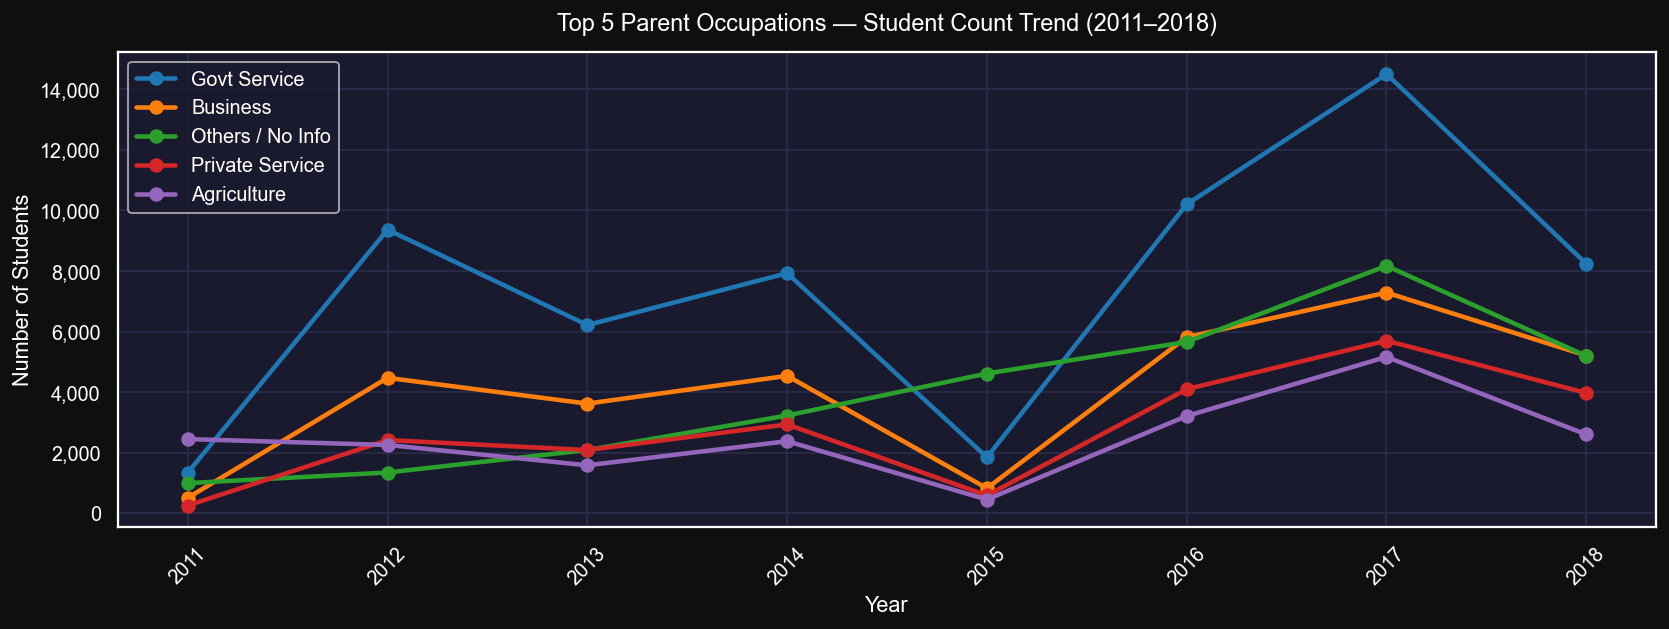

In [71]:
totals    = df[occ_cols].sum().sort_values(ascending=False)
top5_cols = totals.head(5).index.tolist()

fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette("tab10", 5)

for col, color in zip(top5_cols, palette):
    ax.plot(df["Year"], df[col], marker="o", label=col,
            linewidth=2.5, markersize=7, color=color)

ax.set_title("Top 5 Parent Occupations — Student Count Trend (2011–2018)", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Number of Students")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("17_top5_trend.png", bbox_inches="tight")
plt.show()

BLOCK 6 — Govt Service Dominance Analysis

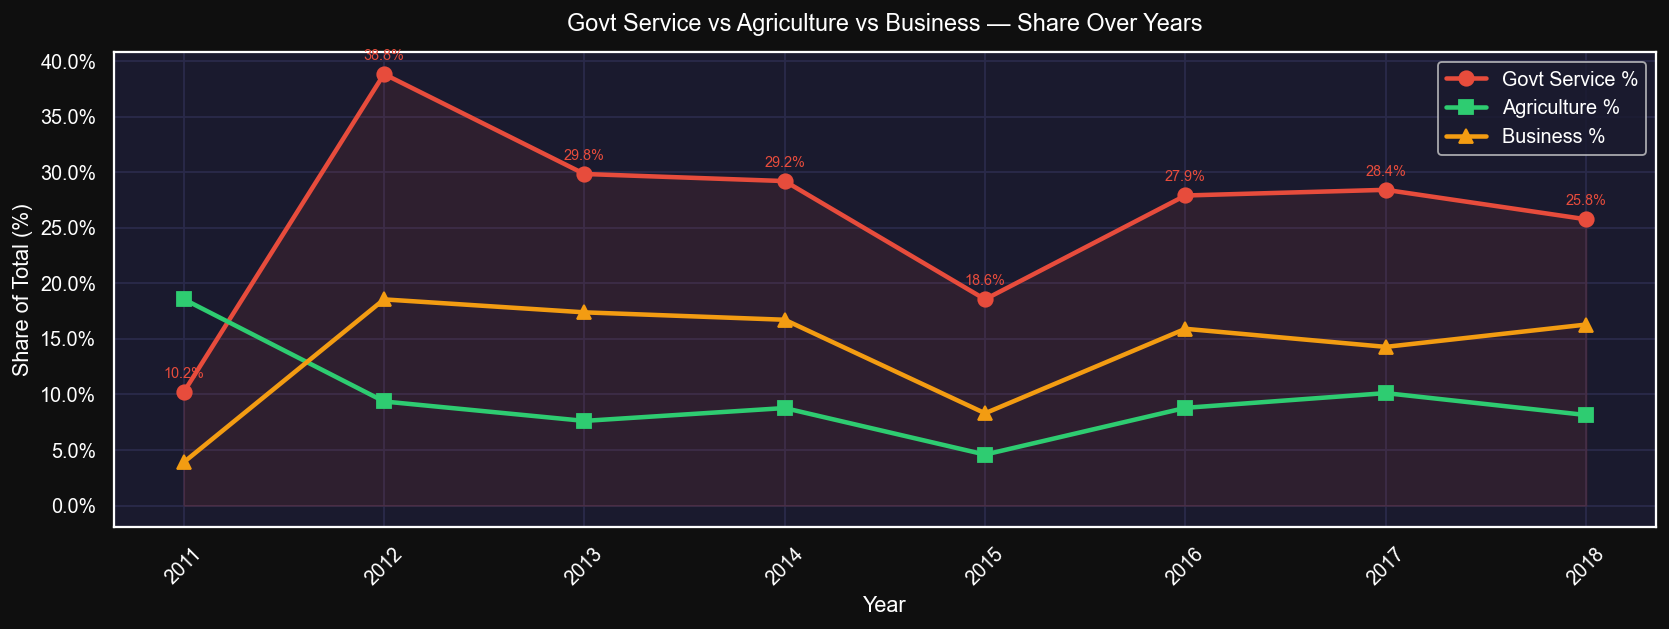

In [72]:
# Govt service is usually dominant — highlight its share
df["GovtShare_pct"] = (df["Govt Service"] / df["Total"]) * 100
df["AgriShare_pct"] = (df["Agriculture"] / df["Total"]) * 100
df["BizShare_pct"]  = (df["Business"]    / df["Total"]) * 100

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df["Year"], df["GovtShare_pct"], marker="o", color="#e74c3c",
        linewidth=2.5, markersize=8, label="Govt Service %")
ax.plot(df["Year"], df["AgriShare_pct"], marker="s", color="#2ecc71",
        linewidth=2.5, markersize=8, label="Agriculture %")
ax.plot(df["Year"], df["BizShare_pct"],  marker="^", color="#f39c12",
        linewidth=2.5, markersize=8, label="Business %")

ax.fill_between(df["Year"], df["GovtShare_pct"], alpha=0.1, color="#e74c3c")

for _, row in df.iterrows():
    ax.annotate(f"{row['GovtShare_pct']:.1f}%",
                xy=(row["Year"], row["GovtShare_pct"]),
                xytext=(0, 8), textcoords="offset points",
                ha="center", fontsize=8, color="#e74c3c")

ax.set_title("Govt Service vs Agriculture vs Business — Share Over Years", fontsize=13, pad=12)
ax.set_xlabel("Year")
ax.set_ylabel("Share of Total (%)")
ax.set_xticks(df["Year"])
ax.set_xticklabels(df["Year"], rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.1f%%"))

plt.tight_layout()
plt.savefig("18_govt_agri_biz.png", bbox_inches="tight")
plt.show()

BLOCK 8 — Pie Chart: All-time Occupation Split

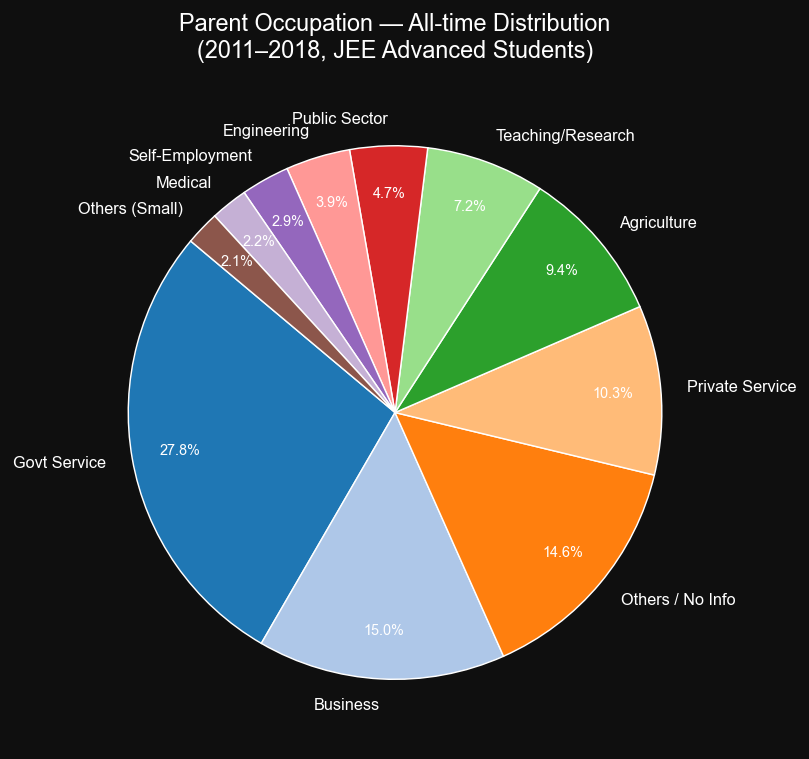

In [73]:
totals = df[occ_cols].sum().sort_values(ascending=False)

# Group small ones into "Others" for clean pie
threshold = totals.sum() * 0.02   # less than 2% → group
main   = totals[totals >= threshold]
others = totals[totals <  threshold].sum()
if others > 0:
    main["Others (Small)"] = others

fig, ax = plt.subplots(figsize=(9, 6))
wedges, texts, autotexts = ax.pie(
    main.values,
    labels=main.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("tab20", len(main)),
    pctdistance=0.82,
    wedgeprops={"edgecolor": "white", "linewidth": 0.8}
)
for t in autotexts:
    t.set_fontsize(8)
    t.set_color("white")
for t in texts:
    t.set_color("white")
    t.set_fontsize(9)

ax.set_title("Parent Occupation — All-time Distribution\n(2011–2018, JEE Advanced Students)", fontsize=13, pad=12)

plt.tight_layout()
plt.savefig("20_occupation_pie.png", bbox_inches="tight")
plt.show()

Registeration fee evolution since 2011

              year          fee
count    15.000000    15.000000
mean   2018.000000  2380.000000
std       4.472136   628.149209
min    2011.000000  1000.000000
25%    2014.500000  2000.000000
50%    2018.000000  2600.000000
75%    2021.500000  2800.000000
max    2025.000000  3200.000000
CAGR: 8.66 %


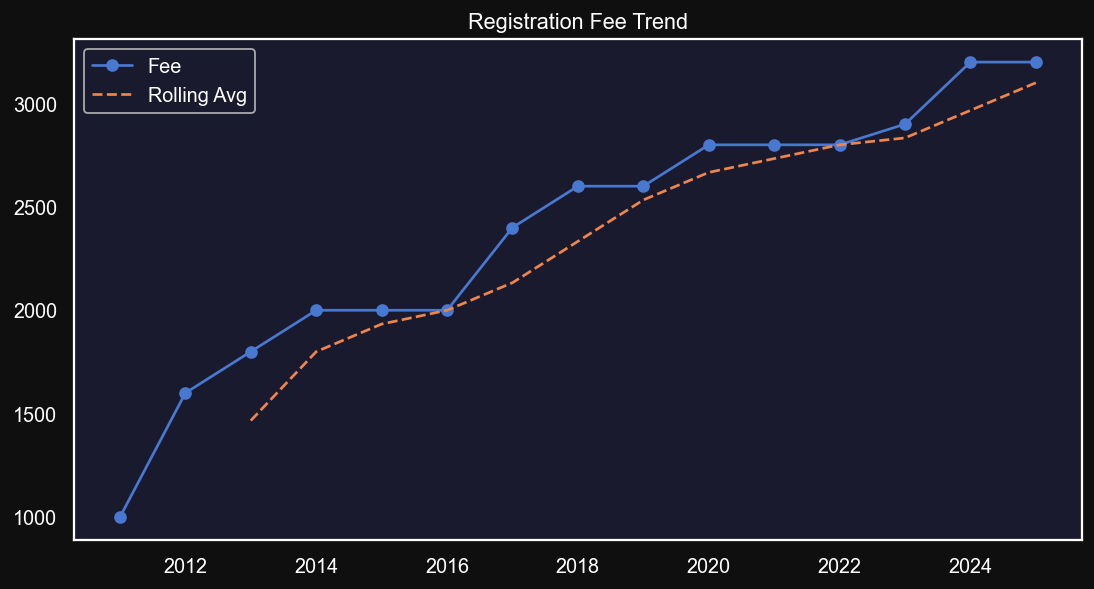

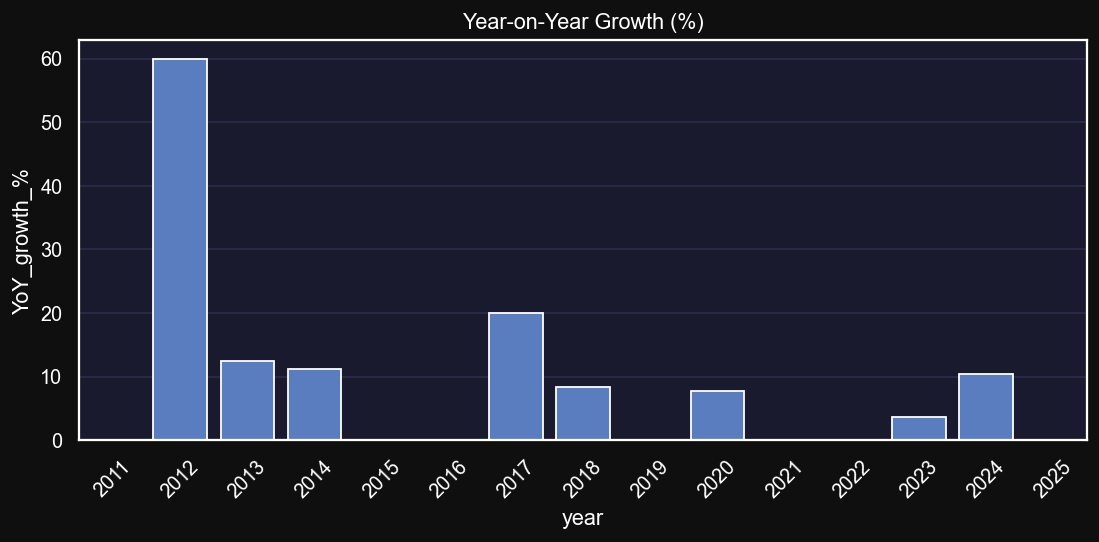

Future Predictions:
   year     pred_fee
0  2026  3462.857143
1  2027  3598.214286
2  2028  3733.571429


In [74]:
# Data
data = {
    "year": list(range(2011, 2026)),
    "fee": [1000,1600,1800,2000,2000,2000,2400,2600,2600,2800,2800,2800,2900,3200,3200]
}

df = pd.DataFrame(data)

# ---- Basic Info ----
print(df.describe())

# ---- YoY Growth ----
df["YoY_growth_%"] = df["fee"].pct_change() * 100

# ---- Rolling Mean ----
df["rolling_avg"] = df["fee"].rolling(window=3).mean()

# ---- CAGR ----
years = df["year"].iloc[-1] - df["year"].iloc[0]
cagr = ((df["fee"].iloc[-1] / df["fee"].iloc[0]) ** (1/years)) - 1
print("CAGR:", round(cagr*100,2), "%")

# ---- Visualization ----
plt.figure(figsize=(10,5))
plt.plot(df["year"], df["fee"], marker='o', label="Fee")
plt.plot(df["year"], df["rolling_avg"], linestyle='--', label="Rolling Avg")
plt.title("Registration Fee Trend")
plt.legend()
plt.grid()
plt.savefig("regfee.png")
plt.show()

# ---- YoY Growth Plot ----
plt.figure(figsize=(10,4))
sns.barplot(x="year", y="YoY_growth_%", data=df)
plt.xticks(rotation=45)
plt.title("Year-on-Year Growth (%)")
plt.savefig("yoy.png")
plt.show()


# ---- Simple Trend Model ----
from sklearn.linear_model import LinearRegression

X = df[["year"]]
y = df["fee"]

model = LinearRegression()
model.fit(X, y)

# Predict next 3 years
future_years = pd.DataFrame({"year": [2026, 2027, 2028]})
pred = model.predict(future_years)

print("Future Predictions:")
print(pd.DataFrame({"year": future_years["year"], "pred_fee": pred}))


BLOCK 9 — Summary Print